In [ ]:
# === CELL 0 ===

!pip install numpy==1.26.4 --force-reinstall -q
!pip install scipy==1.11.4 --force-reinstall -q
!pip install scikit-learn==1.3.2 --force-reinstall -q
!pip install pandas==2.1.4 --force-reinstall -q
!pip install timm -q

print("All packages fixed ✅ — now restart kernel then run Cell 1")

In [1]:
# === CELL 1 ===

import os
import gc
os.environ['LD_LIBRARY_PATH']    = ''
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device : {device}")

# Free GPU memory info
free  = torch.cuda.mem_get_info()[0] / 1024**3
total = torch.cuda.mem_get_info()[1] / 1024**3
print(f"GPU free     : {free:.2f} GB")
print(f"GPU total    : {total:.2f} GB")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device : cuda
GPU free     : 14.46 GB
GPU total    : 14.56 GB


In [2]:
# === CELL 2 ===

DATASET_ROOT = "/kaggle/input/datasets/reubensuju/celeb-df-v2"

def load_video_paths(dataset_root):
    data     = []
    real_dirs = ["Celeb-real", "YouTube-real"]
    fake_dirs = ["Celeb-synthesis"]

    for folder in real_dirs:
        folder_path = Path(dataset_root) / folder
        if folder_path.exists():
            for video in folder_path.glob("*.mp4"):
                data.append({"path": str(video), "label": 0})

    for folder in fake_dirs:
        folder_path = Path(dataset_root) / folder
        if folder_path.exists():
            for video in folder_path.glob("*.mp4"):
                data.append({"path": str(video), "label": 1})

    df = pd.DataFrame(data)
    print(f"Total videos : {len(df)}")
    print(f"Real videos  : {len(df[df.label == 0])}")
    print(f"Fake videos  : {len(df[df.label == 1])}")
    return df

df = load_video_paths(DATASET_ROOT)
print(df.head())

Total videos : 6529
Real videos  : 890
Fake videos  : 5639
                                                path  label
0  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0
1  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0
2  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0
3  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0
4  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0


In [3]:
# === CELL 3 ===

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def detect_and_crop_face(frame, target_size=224):
    gray  = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) == 0:
        h, w   = frame.shape[:2]
        margin = min(h, w) // 8
        face   = frame[margin:h-margin, margin:w-margin]
        return cv2.resize(face, (target_size, target_size))

    x, y, fw, fh = max(faces, key=lambda f: f[2] * f[3])
    margin = 20
    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(frame.shape[1], x + fw + margin)
    y2 = min(frame.shape[0], y + fh + margin)

    face = frame[y1:y2, x1:x2]
    return cv2.resize(face, (target_size, target_size))

print("OpenCV face detector ready ✅")

OpenCV face detector ready ✅


In [4]:
# === CELL 4 ===

def extract_frames(video_path, num_frames=20, target_size=224):
    cap          = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return None

    indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    frames  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        face  = detect_and_crop_face(frame, target_size)
        frames.append(face)

    cap.release()

    while len(frames) < num_frames:
        frames.append(frames[-1] if frames else
                      np.zeros((target_size, target_size, 3), dtype=np.uint8))

    return np.array(frames[:num_frames], dtype=np.uint8)

print("Frame extractor ready ✅")

Frame extractor ready ✅


In [9]:
# === CELL 5 ===

FRAMES_DIR = "/kaggle/working/extracted_frames"
os.makedirs(FRAMES_DIR, exist_ok=True)

# Check if already extracted
existing = os.listdir(FRAMES_DIR)
print(f"Already extracted : {len(existing)} / {len(df)} videos")

if len(existing) < len(df):
    print("Extracting missing videos...")

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting"):
        save_path = os.path.join(FRAMES_DIR, f"{idx}.npy")
        if os.path.exists(save_path):
            continue
        frames = extract_frames(row['path'])
        if frames is None:
            continue
        np.save(save_path, frames)

    print(f"Done! Total saved : {len(os.listdir(FRAMES_DIR))}")
else:
    print("All frames already extracted ✅ — skipping")

Already extracted : 2134 / 6529 videos
Extracting missing videos...


Extracting: 100%|██████████| 6529/6529 [1:55:52<00:00,  1.06s/it]  

Done! Total saved : 6529


In [10]:
# === CELL 6 ===

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# Step 1: Train/Test split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Train samples   : {len(train_df)}")
print(f"Test samples    : {len(test_df)}")
print(f"Train real/fake : {(train_df.label==0).sum()} / {(train_df.label==1).sum()}")
print(f"Test  real/fake : {(test_df.label==0).sum()}  / {(test_df.label==1).sum()}")

# Step 2: Dataset class
class CelebDFDataset(Dataset):
    def __init__(self, dataframe, frames_dir):
        self.dataframe    = dataframe.reset_index(drop=True)
        self.frames_dir   = frames_dir
        self.orig_indices = dataframe.index.tolist()
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        orig_idx = self.orig_indices[idx]
        label    = self.dataframe.iloc[idx]['label']
        npy_path = os.path.join(self.frames_dir, f"{orig_idx}.npy")
        frames   = np.load(npy_path)
        frames   = torch.tensor(frames, dtype=torch.float32)
        frames   = frames.permute(0, 3, 1, 2)
        frames   = frames / 255.0
        frames   = (frames - self.mean) / self.std
        return frames, torch.tensor(label, dtype=torch.float32)

# Step 3: Create datasets
train_dataset = CelebDFDataset(train_df, FRAMES_DIR)
test_dataset  = CelebDFDataset(test_df,  FRAMES_DIR)

# Quick test
sample_frames, label = train_dataset[0]
print(f"\nFrame tensor shape : {sample_frames.shape}")
print(f"Label              : {label}")
print("Dataset ready ✅")

Train samples   : 5223
Test samples    : 1306
Train real/fake : 712 / 4511
Test  real/fake : 178  / 1128

Frame tensor shape : torch.Size([20, 3, 224, 224])
Label              : 1.0
Dataset ready ✅


In [11]:
# === CELL 7 (Option C) ===

train_loader = DataLoader(
    train_dataset,
    batch_size=8,       # only change — doubled from 4
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("DataLoaders ready ✅")

Train batches : 653
Test batches  : 164
DataLoaders ready ✅


In [12]:
# === CELL 8 ===

class DeepfakeDetector(nn.Module):
    def __init__(self, hidden_size=512, num_layers=2, dropout=0.5, chunk_size=5):
        super(DeepfakeDetector, self).__init__()
        self.chunk_size = chunk_size

        self.cnn = timm.create_model(
            'efficientnet_b4',
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )

        for name, param in self.cnn.named_parameters():
            if 'blocks.6' in name or 'blocks.5' in name or 'conv_head' in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        self.bilstm = nn.LSTM(
            input_size=1792,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        feature_chunks = []

        for i in range(0, T, self.chunk_size):
            chunk = x[:, i:i+self.chunk_size]
            chunk = chunk.contiguous().view(-1, C, H, W)
            with torch.cuda.amp.autocast():
                feat = self.cnn(chunk)
            feature_chunks.append(feat.view(B, -1, 1792))

        features    = torch.cat(feature_chunks, dim=1)
        lstm_out, _ = self.bilstm(features)
        out         = lstm_out[:, -1, :]
        out         = self.classifier(out)
        return out.squeeze(1)


model = DeepfakeDetector(
    hidden_size=512,
    num_layers=2,
    dropout=0.5,
    chunk_size=5
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {total_params - trainable_params:,}")
print(f"Model on device      : {next(model.parameters()).device}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Total parameters     : 33,556,297
Trainable parameters : 29,916,729
Frozen parameters    : 3,639,568
Model on device      : cuda:0


In [13]:
# === CELL 9 ===

real_count = (train_df.label == 0).sum()
fake_count = (train_df.label == 1).sum()
pos_weight = torch.tensor([real_count / fake_count],
                           dtype=torch.float32).to(device)

print(f"Real count : {real_count}")
print(f"Fake count : {fake_count}")
print(f"Pos weight : {pos_weight.item():.4f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW([
    {'params': model.cnn.parameters(),        'lr': 1e-5},
    {'params': model.bilstm.parameters(),     'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-4},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

print(f"\nLoss      : BCEWithLogitsLoss")
print(f"Optimizer : AdamW")
print(f"Scheduler : ReduceLROnPlateau")

Real count : 712
Fake count : 4511
Pos weight : 0.1578

Loss      : BCEWithLogitsLoss
Optimizer : AdamW
Scheduler : ReduceLROnPlateau


In [14]:
# === CELL 10 ===

scaler             = GradScaler()
ACCUMULATION_STEPS = 4
NUM_EPOCHS         = 10
best_auc           = 0.0
best_model_path    = "/kaggle/working/best_deepfake_model.pth"

history = {
    'train_loss': [], 'train_auc': [], 'train_acc': [],
    'test_loss':  [], 'test_auc':  [], 'test_acc':  []
}


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_labels = []
    all_preds  = []
    optimizer.zero_grad()

    for batch_idx, (frames, labels) in enumerate(tqdm(loader, desc="Training")):
        frames = frames.to(device)
        labels = labels.to(device)

        with torch.cuda.amp.autocast():
            outputs = model(frames)
            loss    = criterion(outputs, labels)
            loss    = loss / ACCUMULATION_STEPS

        if torch.isnan(loss) or torch.isinf(loss):
            optimizer.zero_grad()
            continue

        scaler.scale(loss).backward()

        if (batch_idx + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * ACCUMULATION_STEPS

        preds = torch.sigmoid(outputs).detach().cpu()
        preds = torch.clamp(preds, 1e-7, 1 - 1e-7)
        all_labels.extend(labels.cpu().tolist())
        all_preds.extend(preds.tolist())

        if batch_idx % 100 == 0:
            torch.cuda.empty_cache()

    avg_loss     = total_loss / len(loader)
    auc          = roc_auc_score(all_labels, all_preds)
    preds_binary = [1 if p >= 0.5 else 0 for p in all_preds]
    acc          = accuracy_score(all_labels, preds_binary)
    return avg_loss, auc, acc


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_labels = []
    all_preds  = []

    with torch.no_grad():
        for batch_idx, (frames, labels) in enumerate(tqdm(loader, desc="Evaluating")):
            frames = frames.to(device)
            labels = labels.to(device)

            with torch.cuda.amp.autocast():
                outputs = model(frames)
                loss    = criterion(outputs, labels)

            if torch.isnan(loss) or torch.isinf(loss):
                continue

            total_loss += loss.item()

            preds = torch.sigmoid(outputs).detach().cpu()
            preds = torch.clamp(preds, 1e-7, 1 - 1e-7)
            all_labels.extend(labels.cpu().tolist())
            all_preds.extend(preds.tolist())

            if batch_idx % 100 == 0:
                torch.cuda.empty_cache()

    avg_loss     = total_loss / len(loader)
    auc          = roc_auc_score(all_labels, all_preds)
    preds_binary = [1 if p >= 0.5 else 0 for p in all_preds]
    acc          = accuracy_score(all_labels, preds_binary)
    return avg_loss, auc, acc


# ── Training from epoch 1 ─────────────────────────────────────────
for epoch in range(0, NUM_EPOCHS):
    print(f"\n{'='*55}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*55}")

    train_loss, train_auc, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device)

    test_loss, test_auc, test_acc = evaluate(
        model, test_loader, criterion, device)

    scheduler.step(test_loss)

    if test_auc > best_auc:
        best_auc = test_auc
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✅ Best model saved (AUC: {best_auc:.4f})")

    # Save checkpoint after every epoch
    torch.save({
        'epoch'          : epoch,
        'model_state'    : model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'best_auc'       : best_auc,
        'history'        : history,
    }, '/kaggle/working/checkpoint.pth')

    history['train_loss'].append(train_loss)
    history['train_auc'].append(train_auc)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_auc'].append(test_auc)
    history['test_acc'].append(test_acc)

    print(f"\n  Train → Loss: {train_loss:.4f} | AUC: {train_auc:.4f} | Acc: {train_acc:.4f}")
    print(f"  Test  → Loss: {test_loss:.4f}  | AUC: {test_auc:.4f}  | Acc: {test_acc:.4f}")

print(f"\n🏆 Best Test AUC: {best_auc:.4f}")

/tmp/ipykernel_596/592710193.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler             = GradScaler()



Epoch 1/10


Training:   0%|          | 0/653 [00:00<?, ?it/s]/tmp/ipykernel_596/592710193.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_596/592710193.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:27<00:00,  1.87it/s]


  ✅ Best model saved (AUC: 0.8599)

  Train → Loss: 0.1744 | AUC: 0.6807 | Acc: 0.6816
  Test  → Loss: 0.1406  | AUC: 0.8599  | Acc: 0.7534

Epoch 2/10


Training:   0%|          | 0/653 [00:00<?, ?it/s]/tmp/ipykernel_596/592710193.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_596/592710193.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:23<00:00,  1.97it/s]


...


  Train → Loss: 0.0461 | AUC: 0.9849 | Acc: 0.9491
  Test  → Loss: 0.1004  | AUC: 0.9415  | Acc: 0.8882

Epoch 9/10


Training:   0%|          | 0/653 [00:00<?, ?it/s]/tmp/ipykernel_596/592710193.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_596/592710193.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:10<00:00,  2.33it/s]


  ✅ Best model saved (AUC: 0.9471)

  Train → Loss: 0.0419 | AUC: 0.9880 | Acc: 0.9608
  Test  → Loss: 0.1151  | AUC: 0.9471  | Acc: 0.9387

Epoch 10/10


Training:   0%|          | 0/653 [00:00<?, ?it/s]/tmp/ipykernel_596/592710193.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_596/592710193.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:10<00:00,  2.32it/s]


  ✅ Best model saved (AUC: 0.9533)

  Train → Loss: 0.0363 | AUC: 0.9906 | Acc: 0.9675
  Test  → Loss: 0.1543  | AUC: 0.9533  | Acc: 0.9479

🏆 Best Test AUC: 0.9533


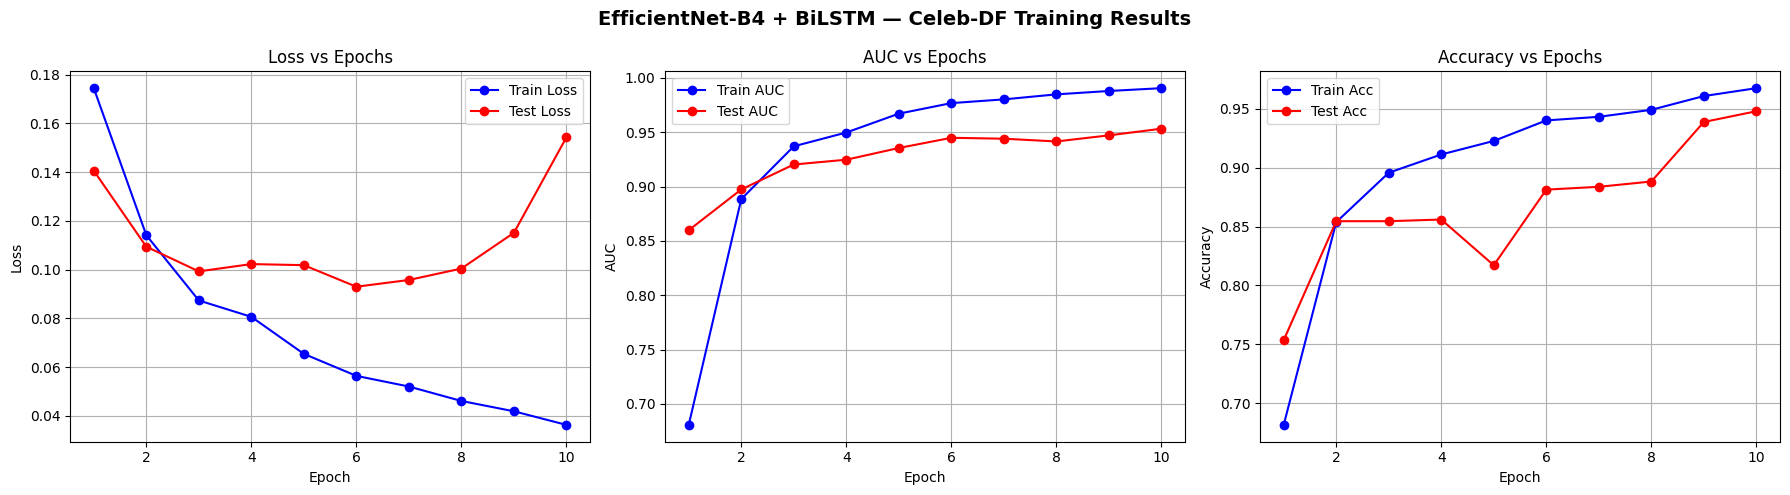

Plot saved ✅


In [17]:
# === CELL 11 ===

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, NUM_EPOCHS + 1)

# Plot 1 — Loss
axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs, history['test_loss'],  'r-o', label='Test Loss')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot 2 — AUC
axes[1].plot(epochs, history['train_auc'], 'b-o', label='Train AUC')
axes[1].plot(epochs, history['test_auc'],  'r-o', label='Test AUC')
axes[1].set_title('AUC vs Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True)

# Plot 3 — Accuracy
axes[2].plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
axes[2].plot(epochs, history['test_acc'],  'r-o', label='Test Acc')
axes[2].set_title('Accuracy vs Epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('EfficientNet-B4 + BiLSTM — Celeb-DF Training Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✅")

Generating predictions:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Generating predictions: 100%|██████████| 164/164 [01:14<00:00,  2.20it/s]


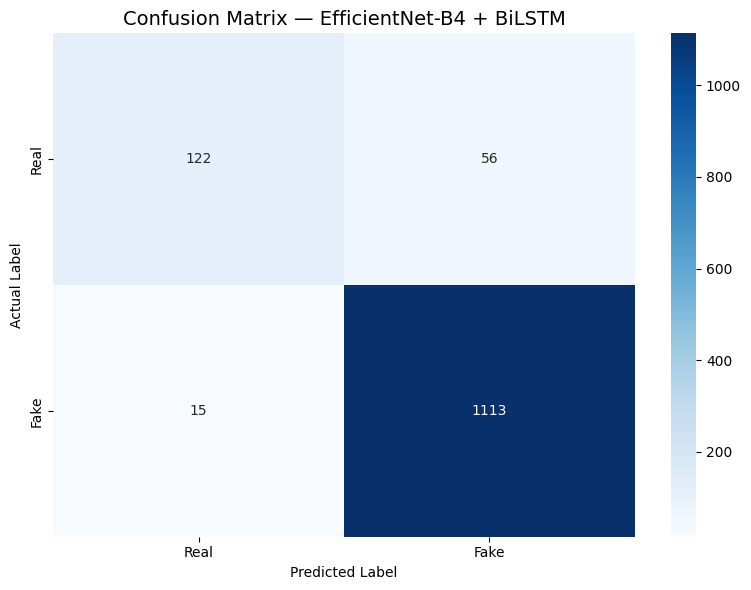


Classification Report:
              precision    recall  f1-score   support

        Real       0.89      0.69      0.77       178
        Fake       0.95      0.99      0.97      1128

    accuracy                           0.95      1306
   macro avg       0.92      0.84      0.87      1306
weighted avg       0.94      0.95      0.94      1306

True  Negatives  (Real  → Real)  : 122
False Positives  (Real  → Fake)  : 56
False Negatives  (Fake  → Real)  : 15
True  Positives  (Fake  → Fake)  : 1113


In [18]:
# === CELL 12 ===

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Load best model
model.load_state_dict(torch.load('/kaggle/working/best_deepfake_model.pth'))
model.eval()

all_labels = []
all_preds  = []
all_probs  = []

with torch.no_grad():
    for frames, labels in tqdm(test_loader, desc="Generating predictions"):
        frames = frames.to(device)
        labels = labels.to(device)

        with torch.amp.autocast('cuda'):
            outputs = model(frames)

        probs  = torch.sigmoid(outputs).detach().cpu()
        probs  = torch.clamp(probs, 1e-7, 1 - 1e-7)
        preds  = (probs >= 0.5).float()

        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix — EfficientNet-B4 + BiLSTM', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=['Real', 'Fake']))

# Summary
tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives  (Real  → Real)  : {tn}")
print(f"False Positives  (Real  → Fake)  : {fp}")
print(f"False Negatives  (Fake  → Real)  : {fn}")
print(f"True  Positives  (Fake  → Fake)  : {tp}")

In [19]:
# === CELL 13 ===

def predict_video(video_path, model, device, num_frames=20, target_size=224):
    """Predict if a video is Real or Fake"""
    model.eval()

    # Extract frames
    print(f"Extracting frames from: {video_path}")
    frames = extract_frames(video_path, num_frames, target_size)

    if frames is None:
        print("Could not extract frames!")
        return

    # Convert to tensor
    frames = torch.tensor(frames, dtype=torch.float32)
    frames = frames.permute(0, 3, 1, 2)       # (20, 3, 224, 224)
    frames = frames / 255.0
    mean   = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std    = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    frames = (frames - mean) / std
    frames = frames.unsqueeze(0).to(device)    # (1, 20, 3, 224, 224)

    # Predict
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            output = model(frames)
        prob = torch.sigmoid(output).item()
        prob = max(1e-7, min(1 - 1e-7, prob))

    label      = "FAKE" if prob >= 0.5 else "REAL"
    confidence = prob if prob >= 0.5 else 1 - prob

    print(f"\n{'='*40}")
    print(f"  Video    : {os.path.basename(video_path)}")
    print(f"  Result   : {label}")
    print(f"  Confidence : {confidence*100:.2f}%")
    print(f"  Fake prob  : {prob*100:.2f}%")
    print(f"  Real prob  : {(1-prob)*100:.2f}%")
    print(f"{'='*40}")

    return label, confidence


# Test on a real video
real_video = df[df.label == 0]['path'].iloc[0]
predict_video(real_video, model, device)

print()

# Test on a fake video
fake_video = df[df.label == 1]['path'].iloc[0]
predict_video(fake_video, model, device)

Extracting frames from: /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real/id49_0006.mp4


/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



  Video    : id49_0006.mp4
  Result   : REAL
  Confidence : 74.41%
  Fake prob  : 25.59%
  Real prob  : 74.41%

Extracting frames from: /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-synthesis/id33_id20_0005.mp4

  Video    : id33_id20_0005.mp4
  Result   : FAKE
  Confidence : 99.66%
  Fake prob  : 99.66%
  Real prob  : 0.34%


('FAKE', 0.99658203125)

In [20]:
# === CELL 14 (Fixed) ===

import math
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Filter out NaN predictions
clean_labels = []
clean_probs  = []
clean_preds  = []

for label, prob, pred in zip(all_labels, all_probs, all_preds):
    if not math.isnan(prob):
        clean_labels.append(label)
        clean_probs.append(prob)
        clean_preds.append(pred)

print(f"Total predictions : {len(all_probs)}")
print(f"NaN removed       : {len(all_probs) - len(clean_probs)}")
print(f"Clean predictions : {len(clean_probs)}")

# Compute metrics
auc       = roc_auc_score(clean_labels, clean_probs)
acc       = accuracy_score(clean_labels, clean_preds)
precision = precision_score(clean_labels, clean_preds)
recall    = recall_score(clean_labels, clean_preds)
f1        = f1_score(clean_labels, clean_preds)
tn, fp, fn, tp = confusion_matrix(clean_labels, clean_preds).ravel()

print("="*55)
print("   FINAL MODEL EVALUATION SUMMARY")
print("="*55)

print(f"\n📌 Model Architecture:")
print(f"   Backbone     : EfficientNet-B4")
print(f"   Temporal     : BiLSTM (hidden=512, layers=2)")
print(f"   Input frames : 20 frames per video")
print(f"   Face detector: OpenCV Haar Cascade")
print(f"   Dataset      : Celeb-DF v2")

print(f"\n📌 Dataset Split:")
print(f"   Total videos : 6529")
print(f"   Train        : 5223 (80%)")
print(f"   Test         : 1306 (20%)")
print(f"   Real videos  : 890")
print(f"   Fake videos  : 5639")

print(f"\n📌 Training:")
print(f"   Epochs       : 10")
print(f"   Batch size   : 8")
print(f"   Optimizer    : AdamW")
print(f"   Scheduler    : ReduceLROnPlateau")
print(f"   Loss         : BCEWithLogitsLoss")

print(f"\n📌 Final Test Results:")
print(f"   AUC          : {auc:.4f}  ({auc*100:.2f}%)")
print(f"   Accuracy     : {acc:.4f}  ({acc*100:.2f}%)")
print(f"   Precision    : {precision:.4f}  ({precision*100:.2f}%)")
print(f"   Recall       : {recall:.4f}  ({recall*100:.2f}%)")
print(f"   F1 Score     : {f1:.4f}  ({f1*100:.2f}%)")

print(f"\n📌 Confusion Matrix:")
print(f"   True  Real (TN) : {tn}")
print(f"   False Fake (FP) : {fp}")
print(f"   False Real (FN) : {fn}")
print(f"   True  Fake (TP) : {tp}")

print(f"\n📌 Saved Files:")
print(f"   Best model      : /kaggle/working/best_deepfake_model.pth")
print(f"   Checkpoint      : /kaggle/working/checkpoint.pth")
print(f"   Training plot   : /kaggle/working/training_results.png")
print(f"   Confusion matrix: /kaggle/working/confusion_matrix.png")
print("="*55)

Total predictions : 1306
NaN removed       : 5
Clean predictions : 1301
   FINAL MODEL EVALUATION SUMMARY

📌 Model Architecture:
   Backbone     : EfficientNet-B4
   Temporal     : BiLSTM (hidden=512, layers=2)
   Input frames : 20 frames per video
   Face detector: OpenCV Haar Cascade
   Dataset      : Celeb-DF v2

📌 Dataset Split:
   Total videos : 6529
   Train        : 5223 (80%)
   Test         : 1306 (20%)
   Real videos  : 890
   Fake videos  : 5639

📌 Training:
   Epochs       : 10
   Batch size   : 8
   Optimizer    : AdamW
   Scheduler    : ReduceLROnPlateau
   Loss         : BCEWithLogitsLoss

📌 Final Test Results:
   AUC          : 0.9538  (95.38%)
   Accuracy     : 0.9485  (94.85%)
   Precision    : 0.9521  (95.21%)
   Recall       : 0.9902  (99.02%)
   F1 Score     : 0.9708  (97.08%)

📌 Confusion Matrix:
   True  Real (TN) : 121
   False Fake (FP) : 56
   False Real (FN) : 11
   True  Fake (TP) : 1113

📌 Saved Files:
   Best model      : /kaggle/working/best_deepfake_mode

In [30]:
import os
print(os.listdir("/kaggle/input/datasets"))

['gradientvoyager', 'reubensuju']


In [26]:
import os

FFPP_ROOT = "/kaggle/input/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k"
print(os.listdir(FFPP_ROOT))

['dataset_processed_split']


In [27]:
import pandas as pd

manifest_path = f"{FFPP_ROOT}/dataset_processed_split/dataset_manifest.csv"
manifest = pd.read_csv(manifest_path)

print(manifest.shape)
print(manifest.columns.tolist())
print(manifest.head(10))

(182246, 6)
['filename', 'source_id', 'frame_idx', 'label', 'fake_type', 'split']
       filename  source_id  frame_idx label fake_type  split
0    796_f0.jpg        796          0  REAL      Real  train
1    836_f0.jpg        836          0  REAL      Real  train
2   796_f34.jpg        796         34  REAL      Real  train
3   836_f11.jpg        836         11  REAL      Real  train
4   836_f23.jpg        836         23  REAL      Real  train
5   796_f68.jpg        796         68  REAL      Real  train
6   836_f35.jpg        836         35  REAL      Real  train
7    955_f0.jpg        955          0  REAL      Real   test
8    478_f0.jpg        478          0  REAL      Real  train
9  796_f103.jpg        796        103  REAL      Real  train


In [28]:
print(manifest['fake_type'].value_counts())
print(manifest['label'].value_counts())
print(manifest['split'].value_counts())

# check where actual image files live relative to split folders
import os
test_dir = f"{FFPP_ROOT}/dataset_processed_split/test"
print(os.listdir(test_dir)[:10])

fake_type
FaceSwap             27138
Real                 26444
Face2Face            26424
DeepFakeDetection    26165
Deepfakes            25977
FaceShifter          25085
NeuralTextures       25013
Name: count, dtype: int64
label
FAKE    155802
REAL     26444
Name: count, dtype: int64
split
train    128477
val       27493
test      26276
Name: count, dtype: int64
['Face2Face', 'Deepfakes', 'DeepFakeDetection', 'Real', 'NeuralTextures', 'FaceShifter', 'FaceSwap']


In [33]:
# === Cross-model generalization: FF++ (NeuralTextures) as unseen domain ===

import cv2
import math
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm import tqdm

FFPP_SPLIT_ROOT = f"{FFPP_ROOT}/dataset_processed_split"

class FFPPVideoDataset(Dataset):
    """
    Groups frame-level FF++ images by source_id into 20-frame clips,
    matching the (T, C, H, W) format CelebDFDataset/DeepfakeDetector expects.
    """
    def __init__(self, manifest_df, root, num_frames=20, target_size=224):
        self.root = root
        self.num_frames = num_frames
        self.target_size = target_size
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

        groups = manifest_df.groupby(['source_id', 'fake_type', 'split', 'label'])
        self.clips = []
        for (source_id, fake_type, split, label), g in groups:
            g_sorted = g.sort_values('frame_idx')
            filenames = g_sorted['filename'].tolist()
            self.clips.append({
                'filenames': filenames,
                'fake_type': fake_type,
                'split': split,
                'label': 0 if label == 'REAL' else 1
            })

    def __len__(self):
        return len(self.clips)

    def _load_and_sample(self, clip):
        filenames = clip['filenames']
        n = len(filenames)
        if n == 0:
            return np.zeros((self.num_frames, self.target_size, self.target_size, 3), dtype=np.uint8)

        indices = np.linspace(0, n - 1, self.num_frames).astype(int)
        frames = []
        for i in indices:
            fname = filenames[i]
            img_path = f"{self.root}/{clip['split']}/{clip['fake_type']}/{fname}"
            img = cv2.imread(img_path)
            if img is None:
                frames.append(frames[-1] if frames else
                              np.zeros((self.target_size, self.target_size, 3), dtype=np.uint8))
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.target_size, self.target_size))
            frames.append(img)
        return np.array(frames, dtype=np.uint8)

    def __getitem__(self, idx):
        clip = self.clips[idx]
        frames = self._load_and_sample(clip)
        frames = torch.tensor(frames, dtype=torch.float32)
        frames = frames.permute(0, 3, 1, 2)
        frames = frames / 255.0
        frames = (frames - self.mean) / self.std
        label = clip['label']
        return frames, torch.tensor(label, dtype=torch.float32)


# Build cross-domain test set: NeuralTextures fakes + Real, from FF++ 'test' split only
test_manifest = manifest[manifest['split'] == 'test']
cross_df = test_manifest[test_manifest['fake_type'].isin(['NeuralTextures', 'Real'])]
print(cross_df['fake_type'].value_counts())

cross_dataset = FFPPVideoDataset(cross_df, root=FFPP_SPLIT_ROOT)
print(f"Number of pseudo-video clips: {len(cross_dataset)}")

cross_loader = DataLoader(cross_dataset, batch_size=8, shuffle=False, num_workers=0)


def evaluate_cross_model(model, dataloader, device):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for frames, labels in tqdm(dataloader, desc="Cross-domain eval"):
            frames = frames.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(frames)
            probs = torch.sigmoid(outputs).detach().cpu()
            probs = torch.clamp(probs, 1e-7, 1 - 1e-7)
            all_labels.extend(labels.tolist())
            all_probs.extend(probs.tolist())

    # filter NaNs (occasional fp16/autocast artifact)
    clean_labels, clean_probs = [], []
    for label, prob in zip(all_labels, all_probs):
        if not math.isnan(prob):
            clean_labels.append(label)
            clean_probs.append(prob)
    print(f"NaN removed: {len(all_probs) - len(clean_probs)} / {len(all_probs)}")

    auc = roc_auc_score(clean_labels, clean_probs)
    preds_binary = [1 if p >= 0.5 else 0 for p in clean_probs]
    acc = accuracy_score(clean_labels, preds_binary)
    return auc, acc


cross_domain_auc, cross_domain_acc = evaluate_cross_model(model, cross_loader, device)
print(f"\nCross-domain (FF++ NeuralTextures) -> AUC: {cross_domain_auc:.4f}, Acc: {cross_domain_acc:.4f}")
print(f"In-domain    (Celeb-DF-v2)          -> AUC: {auc:.4f}, Acc: {acc:.4f}")  # from Cell 14

fake_type
Real              3944
NeuralTextures    3744
Name: count, dtype: int64
Number of pseudo-video clips: 272


Cross-domain eval:   0%|          | 0/34 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Cross-domain eval: 100%|██████████| 34/34 [00:49<00:00,  1.44s/it]

NaN removed: 2 / 272

Cross-domain (FF++ NeuralTextures) -> AUC: 0.6228, Acc: 0.5667
In-domain    (Celeb-DF-v2)          -> AUC: 0.9538, Acc: 0.9485


In [34]:
# === Domain shift via degradation (3.6.2) ===

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score
import math

# --- Degradation functions (applied per-frame, uint8 RGB, before normalization) ---

def apply_jpeg(frame, quality):
    _, enc = cv2.imencode('.jpg', frame, [cv2.IMWRITE_JPEG_QUALITY, quality])
    return cv2.imdecode(enc, cv2.IMREAD_COLOR)

def apply_blur(frame, k):
    if k <= 1:
        return frame
    return cv2.GaussianBlur(frame, (k, k), 0)

def apply_downscale(frame, factor):
    if factor <= 1:
        return frame
    h, w = frame.shape[:2]
    small = cv2.resize(frame, (max(1, w // factor), max(1, h // factor)))
    return cv2.resize(small, (w, h))

def apply_brightness(frame, delta):
    return np.clip(frame.astype(int) + delta, 0, 255).astype(np.uint8)


class DegradedCelebDFDataset(Dataset):
    """
    Same as CelebDFDataset, but applies a degradation function to every
    frame before normalization. Pass degrade_fn=None for clean baseline.
    """
    def __init__(self, dataframe, frames_dir, degrade_fn=None):
        self.dataframe    = dataframe.reset_index(drop=True)
        self.frames_dir   = frames_dir
        self.orig_indices = dataframe.index.tolist()
        self.degrade_fn   = degrade_fn
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        orig_idx = self.orig_indices[idx]
        label    = self.dataframe.iloc[idx]['label']
        npy_path = os.path.join(self.frames_dir, f"{orig_idx}.npy")
        frames   = np.load(npy_path)  # (T, H, W, 3) uint8 RGB

        if self.degrade_fn is not None:
            frames = np.array([self.degrade_fn(f) for f in frames], dtype=np.uint8)

        frames = torch.tensor(frames, dtype=torch.float32)
        frames = frames.permute(0, 3, 1, 2)
        frames = frames / 255.0
        frames = (frames - self.mean) / self.std
        return frames, torch.tensor(label, dtype=torch.float32)


def evaluate_degraded(model, dataloader, device):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for frames, labels in tqdm(dataloader, desc="Evaluating"):
            frames = frames.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(frames)
            probs = torch.sigmoid(outputs).detach().cpu()
            probs = torch.clamp(probs, 1e-7, 1 - 1e-7)
            all_labels.extend(labels.tolist())
            all_probs.extend(probs.tolist())

    clean_labels, clean_probs = [], []
    for label, prob in zip(all_labels, all_probs):
        if not math.isnan(prob):
            clean_labels.append(label)
            clean_probs.append(prob)

    auc = roc_auc_score(clean_labels, clean_probs)
    preds_binary = [1 if p >= 0.5 else 0 for p in clean_probs]
    acc = accuracy_score(clean_labels, preds_binary)
    return auc, acc


# --- Run the degradation sweep ---
results = {}

# Clean baseline (sanity check — should match your Cell 14 test AUC ~0.95)
clean_dataset = DegradedCelebDFDataset(test_df, FRAMES_DIR, degrade_fn=None)
clean_loader  = DataLoader(clean_dataset, batch_size=8, shuffle=False, num_workers=0)
auc, acc = evaluate_degraded(model, clean_loader, device)
results['clean'] = (auc, acc)
print(f"Clean        -> AUC: {auc:.4f}, Acc: {acc:.4f}")

# JPEG compression sweep
for quality in [70, 50, 30, 10]:
    ds = DegradedCelebDFDataset(test_df, FRAMES_DIR, degrade_fn=lambda f, q=quality: apply_jpeg(f, q))
    loader = DataLoader(ds, batch_size=8, shuffle=False, num_workers=0)
    auc, acc = evaluate_degraded(model, loader, device)
    results[f'jpeg_{quality}'] = (auc, acc)
    print(f"JPEG q={quality:<4} -> AUC: {auc:.4f}, Acc: {acc:.4f}")

# Gaussian blur sweep
for k in [3, 5, 7, 9]:
    ds = DegradedCelebDFDataset(test_df, FRAMES_DIR, degrade_fn=lambda f, k=k: apply_blur(f, k))
    loader = DataLoader(ds, batch_size=8, shuffle=False, num_workers=0)
    auc, acc = evaluate_degraded(model, loader, device)
    results[f'blur_{k}'] = (auc, acc)
    print(f"Blur k={k:<4}  -> AUC: {auc:.4f}, Acc: {acc:.4f}")

# Downscale sweep
for factor in [2, 3, 4]:
    ds = DegradedCelebDFDataset(test_df, FRAMES_DIR, degrade_fn=lambda f, s=factor: apply_downscale(f, s))
    loader = DataLoader(ds, batch_size=8, shuffle=False, num_workers=0)
    auc, acc = evaluate_degraded(model, loader, device)
    results[f'downscale_{factor}x'] = (auc, acc)
    print(f"Downscale {factor}x -> AUC: {auc:.4f}, Acc: {acc:.4f}")

# Brightness sweep
for delta in [-50, -25, 25, 50]:
    ds = DegradedCelebDFDataset(test_df, FRAMES_DIR, degrade_fn=lambda f, d=delta: apply_brightness(f, d))
    loader = DataLoader(ds, batch_size=8, shuffle=False, num_workers=0)
    auc, acc = evaluate_degraded(model, loader, device)
    results[f'brightness_{delta:+d}'] = (auc, acc)
    print(f"Brightness {delta:+d} -> AUC: {auc:.4f}, Acc: {acc:.4f}")

print("\nAll results:", results)

Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:11<00:00,  2.29it/s]


Clean        -> AUC: 0.9538, Acc: 0.9485


Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:28<00:00,  1.86it/s]


JPEG q=70   -> AUC: 0.9458, Acc: 0.8851


Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:27<00:00,  1.88it/s]


...

Brightness -50 -> AUC: 0.9099, Acc: 0.8226


Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:25<00:00,  1.92it/s]


Brightness +25 -> AUC: 0.9487, Acc: 0.9384


Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:25<00:00,  1.91it/s]

Brightness +50 -> AUC: 0.9441, Acc: 0.9246

All results: {'clean': (0.9537643002191528, 0.9485011529592621), 'jpeg_70': (0.9457828894269572, 0.8851195065535852), 'jpeg_50': (0.8877803990563398, 0.7880184331797235), 'jpeg_30': (0.7720409353197821, 0.6095311299000769), 'jpeg_10': (0.5976842200670716, 0.19091608929946113), 'blur_3': (0.9471272611363455, 0.9249617151607963), 'blur_5': (0.9300243047254761, 0.9127105666156202), 'blur_7': (0.8898592517332058, 0.891271056661562), 'blur_9': (0.8507699816718463, 0.8813169984686064), 'downscale_2x': (0.9275739102717349, 0.9058192955589587), 'downscale_3x': (0.8780754442585066, 0.8422664624808576), 'downscale_4x': (0.7934222846441947, 0.8514548238897397), 'brightness_-50': (0.9098983050847456, 0.8225806451612904), 'brightness_-25': (0.9432140615191462, 0.9416282642089093), 'brightness_+25': (0.9486553126588715, 0.9384141647421094), 'brightness_+50': (0.9441043553866063, 0.9246153846153846)}


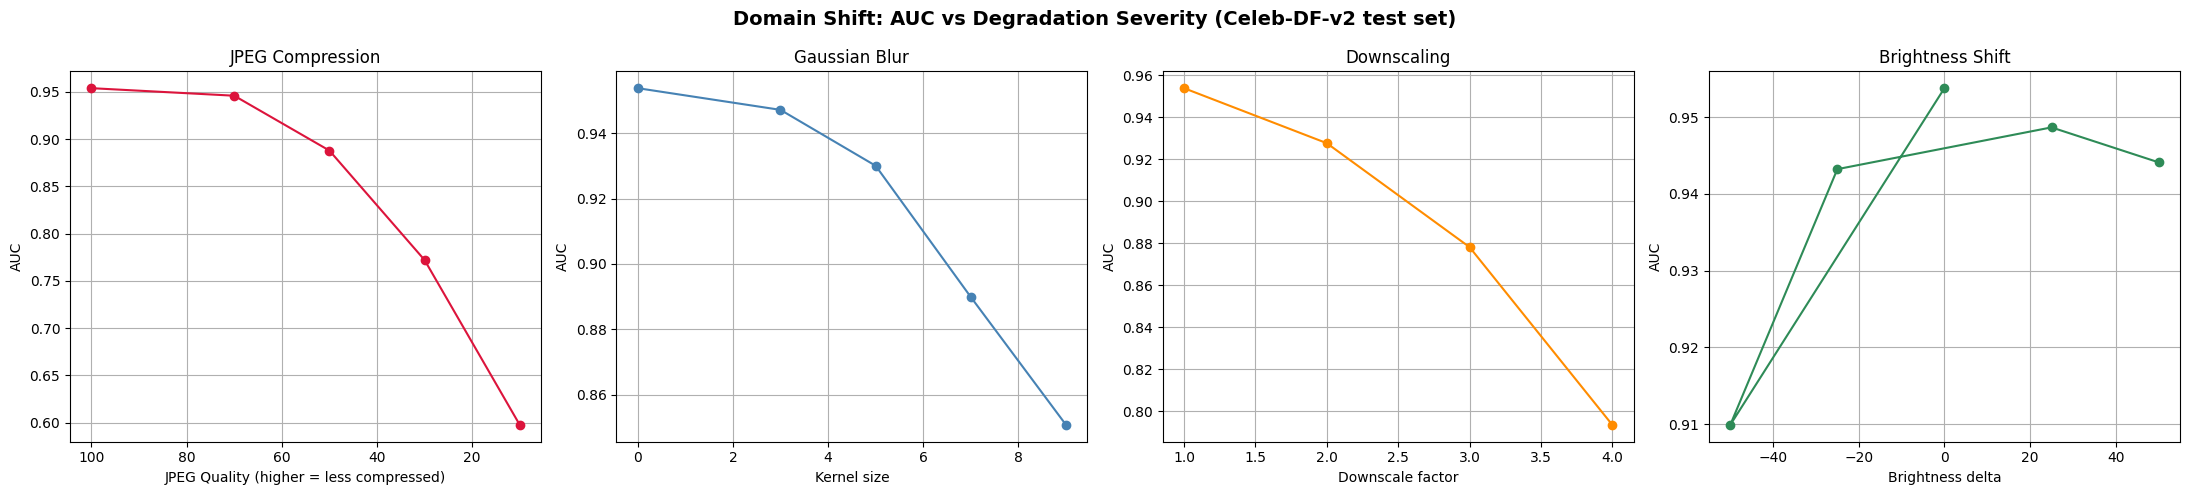

Plot saved ✅


In [35]:
import matplotlib.pyplot as plt

# Group results by degradation type
jpeg_levels = [70, 50, 30, 10]
blur_levels = [3, 5, 7, 9]
downscale_levels = [2, 3, 4]
brightness_levels = [-50, -25, 25, 50]

clean_auc = results['clean'][0]

jpeg_auc = [results[f'jpeg_{q}'][0] for q in jpeg_levels]
blur_auc = [results[f'blur_{k}'][0] for k in blur_levels]
downscale_auc = [results[f'downscale_{f}x'][0] for f in downscale_levels]
brightness_auc = [results[f'brightness_{d:+d}'][0] for d in brightness_levels]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# JPEG (severity increases as quality decreases, so reverse x-axis for intuitive reading)
axes[0].plot([100] + jpeg_levels, [clean_auc] + jpeg_auc, 'o-', color='crimson')
axes[0].invert_xaxis()
axes[0].set_title('JPEG Compression')
axes[0].set_xlabel('JPEG Quality (higher = less compressed)')
axes[0].set_ylabel('AUC')
axes[0].grid(True)

axes[1].plot([0] + blur_levels, [clean_auc] + blur_auc, 'o-', color='steelblue')
axes[1].set_title('Gaussian Blur')
axes[1].set_xlabel('Kernel size')
axes[1].set_ylabel('AUC')
axes[1].grid(True)

axes[2].plot([1] + downscale_levels, [clean_auc] + downscale_auc, 'o-', color='darkorange')
axes[2].set_title('Downscaling')
axes[2].set_xlabel('Downscale factor')
axes[2].set_ylabel('AUC')
axes[2].grid(True)

axes[3].plot([0] + brightness_levels, [clean_auc] + brightness_auc, 'o-', color='seagreen')
axes[3].set_title('Brightness Shift')
axes[3].set_xlabel('Brightness delta')
axes[3].set_ylabel('AUC')
axes[3].grid(True)

plt.suptitle('Domain Shift: AUC vs Degradation Severity (Celeb-DF-v2 test set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/domain_shift_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✅")

In [36]:
# === 3.6.3: Robustness strategy — fine-tuning on a small FF++ sample ===

import copy
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn

# Split your 272 FF++ clips into fine-tune-train / fine-tune-val
clip_indices = list(range(len(cross_dataset)))
clip_labels = [cross_dataset.clips[i]['label'] for i in clip_indices]

ft_train_idx, ft_val_idx = train_test_split(
    clip_indices, test_size=0.2, random_state=42, stratify=clip_labels
)

ft_train_dataset = torch.utils.data.Subset(cross_dataset, ft_train_idx)
ft_val_dataset   = torch.utils.data.Subset(cross_dataset, ft_val_idx)

print(f"Fine-tune train clips: {len(ft_train_dataset)}")
print(f"Fine-tune val clips  : {len(ft_val_dataset)}")

ft_train_loader = DataLoader(ft_train_dataset, batch_size=8, shuffle=True, num_workers=0)
ft_val_loader   = DataLoader(ft_val_dataset, batch_size=8, shuffle=False, num_workers=0)

# Keep a copy of the original (pre-fine-tune) model for comparison
original_state_dict = copy.deepcopy(model.state_dict())

# Lower learning rates for fine-tuning (avoid catastrophic forgetting of Celeb-DF knowledge)
ft_optimizer = optim.AdamW([
    {'params': model.cnn.parameters(),        'lr': 1e-6},
    {'params': model.bilstm.parameters(),     'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-5},
], weight_decay=1e-4)

ft_criterion = nn.BCEWithLogitsLoss()
ft_scaler = torch.cuda.amp.GradScaler()

NUM_FT_EPOCHS = 4

def ft_train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for frames, labels in tqdm(loader, desc="Fine-tune train"):
        frames, labels = frames.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(frames)
            loss = criterion(outputs, labels)
        if torch.isnan(loss) or torch.isinf(loss):
            continue
        ft_scaler.scale(loss).backward()
        ft_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        ft_scaler.step(optimizer)
        ft_scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


def ft_evaluate(model, loader, device):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for frames, labels in tqdm(loader, desc="Fine-tune eval"):
            frames = frames.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(frames)
            probs = torch.sigmoid(outputs).detach().cpu()
            probs = torch.clamp(probs, 1e-7, 1 - 1e-7)
            all_labels.extend(labels.tolist())
            all_probs.extend(probs.tolist())

    clean_labels, clean_probs = [], []
    for label, prob in zip(all_labels, all_probs):
        if not math.isnan(prob):
            clean_labels.append(label)
            clean_probs.append(prob)

    auc = roc_auc_score(clean_labels, clean_probs)
    preds_binary = [1 if p >= 0.5 else 0 for p in clean_probs]
    acc = accuracy_score(clean_labels, preds_binary)
    return auc, acc


# Baseline before fine-tuning (should match your earlier 0.6228 AUC, evaluated on the same val subset)
pre_ft_auc, pre_ft_acc = ft_evaluate(model, ft_val_loader, device)
print(f"\nBEFORE fine-tuning -> AUC: {pre_ft_auc:.4f}, Acc: {pre_ft_acc:.4f}")

# Fine-tune
for epoch in range(NUM_FT_EPOCHS):
    loss = ft_train_one_epoch(model, ft_train_loader, ft_optimizer, ft_criterion, device)
    val_auc, val_acc = ft_evaluate(model, ft_val_loader, device)
    print(f"Epoch {epoch+1}/{NUM_FT_EPOCHS} -> Loss: {loss:.4f}, Val AUC: {val_auc:.4f}, Val Acc: {val_acc:.4f}")

# Final result after fine-tuning
post_ft_auc, post_ft_acc = ft_evaluate(model, ft_val_loader, device)
print(f"\nAFTER fine-tuning  -> AUC: {post_ft_auc:.4f}, Acc: {post_ft_acc:.4f}")
print(f"\nImprovement: ΔAUC = {post_ft_auc - pre_ft_auc:.4f}, ΔAcc = {post_ft_acc - pre_ft_acc:.4f}")

# Save fine-tuned model separately (don't overwrite your original best model)
torch.save(model.state_dict(), '/kaggle/working/finetuned_ffpp_model.pth')
print("\nFine-tuned model saved ✅")

/tmp/ipykernel_596/3597862173.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  ft_scaler = torch.cuda.amp.GradScaler()


Fine-tune train clips: 217
Fine-tune val clips  : 55


Fine-tune eval:   0%|          | 0/7 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fine-tune eval: 100%|██████████| 7/7 [00:06<00:00,  1.16it/s]



BEFORE fine-tuning -> AUC: 0.7381, Acc: 0.5636


Fine-tune train:   0%|          | 0/28 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fine-tune eval: 100%|██████████| 7/7 [00:05<00:00,  1.37it/s]


...

Epoch 3/4 -> Loss: 1.0809, Val AUC: 0.6792, Val Acc: 0.5818


Fine-tune train:   0%|          | 0/28 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fine-tune eval: 100%|██████████| 7/7 [00:04<00:00,  1.40it/s]


Epoch 4/4 -> Loss: 0.9455, Val AUC: 0.6409, Val Acc: 0.5455


Fine-tune eval:   0%|          | 0/7 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fine-tune eval: 100%|██████████| 7/7 [00:04<00:00,  1.41it/s]



AFTER fine-tuning  -> AUC: 0.6409, Acc: 0.5455

Improvement: ΔAUC = -0.0972, ΔAcc = -0.0182

Fine-tuned model saved ✅


In [37]:
# === 3.6.3 (Option 2): Augmentation-based robustness fine-tuning ===

import random
import copy

# Reuse the degradation functions from 3.6.2
def random_augment(frame):
    """Randomly apply one degradation per frame during training, to build robustness."""
    choice = random.choice(['none', 'jpeg', 'blur', 'downscale', 'brightness'])
    if choice == 'none':
        return frame
    elif choice == 'jpeg':
        return apply_jpeg(frame, random.choice([30, 50, 70]))
    elif choice == 'blur':
        return apply_blur(frame, random.choice([3, 5, 7]))
    elif choice == 'downscale':
        return apply_downscale(frame, random.choice([2, 3]))
    elif choice == 'brightness':
        return apply_brightness(frame, random.choice([-40, -20, 20, 40]))
    return frame


class AugmentedCelebDFDataset(Dataset):
    """Same as DegradedCelebDFDataset, but applies RANDOM augmentation per-sample (training only)."""
    def __init__(self, dataframe, frames_dir):
        self.dataframe    = dataframe.reset_index(drop=True)
        self.frames_dir   = frames_dir
        self.orig_indices = dataframe.index.tolist()
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        orig_idx = self.orig_indices[idx]
        label    = self.dataframe.iloc[idx]['label']
        npy_path = os.path.join(self.frames_dir, f"{orig_idx}.npy")
        frames   = np.load(npy_path)
        frames   = np.array([random_augment(f) for f in frames], dtype=np.uint8)
        frames   = torch.tensor(frames, dtype=torch.float32)
        frames   = frames.permute(0, 3, 1, 2)
        frames   = frames / 255.0
        frames   = (frames - self.mean) / self.std
        return frames, torch.tensor(label, dtype=torch.float32)


# Use a SUBSET of train_df to keep this fast (not the full 5223 videos)
TRAIN_SUBSET_SIZE = 400  # adjust down if still too slow
aug_train_df = train_df.sample(n=min(TRAIN_SUBSET_SIZE, len(train_df)), random_state=42)

aug_train_dataset = AugmentedCelebDFDataset(aug_train_df, FRAMES_DIR)
aug_train_loader  = DataLoader(aug_train_dataset, batch_size=8, shuffle=True, num_workers=0)

print(f"Augmented fine-tune set: {len(aug_train_dataset)} clips")

# Save current weights so we can restore the pre-augmentation model for comparison
pre_aug_state_dict = copy.deepcopy(model.state_dict())

aug_optimizer = optim.AdamW([
    {'params': model.cnn.parameters(),        'lr': 1e-6},
    {'params': model.bilstm.parameters(),     'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-5},
], weight_decay=1e-4)

aug_criterion = nn.BCEWithLogitsLoss()
aug_scaler = torch.amp.GradScaler('cuda')

NUM_AUG_EPOCHS = 3

def aug_train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for frames, labels in tqdm(loader, desc="Aug fine-tune train"):
        frames, labels = frames.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(frames)
            loss = criterion(outputs, labels)
        if torch.isnan(loss) or torch.isinf(loss):
            continue
        aug_scaler.scale(loss).backward()
        aug_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        aug_scaler.step(optimizer)
        aug_scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


# --- Measure degraded performance BEFORE augmentation fine-tuning (reuse worst-case JPEG q10 set) ---
jpeg10_ds = DegradedCelebDFDataset(test_df, FRAMES_DIR, degrade_fn=lambda f: apply_jpeg(f, 10))
jpeg10_loader = DataLoader(jpeg10_ds, batch_size=8, shuffle=False, num_workers=0)
pre_aug_auc, pre_aug_acc = evaluate_degraded(model, jpeg10_loader, device)
print(f"\nBEFORE aug fine-tuning (JPEG q10) -> AUC: {pre_aug_auc:.4f}, Acc: {pre_aug_acc:.4f}")

# --- Fine-tune with augmentation ---
for epoch in range(NUM_AUG_EPOCHS):
    loss = aug_train_one_epoch(model, aug_train_loader, aug_optimizer, aug_criterion, device)
    print(f"Epoch {epoch+1}/{NUM_AUG_EPOCHS} -> Loss: {loss:.4f}")

# --- Re-evaluate on the SAME degraded set ---
post_aug_auc, post_aug_acc = evaluate_degraded(model, jpeg10_loader, device)
print(f"\nAFTER aug fine-tuning (JPEG q10)  -> AUC: {post_aug_auc:.4f}, Acc: {post_aug_acc:.4f}")
print(f"Improvement: ΔAUC = {post_aug_auc - pre_aug_auc:.4f}, ΔAcc = {post_aug_acc - pre_aug_acc:.4f}")

torch.save(model.state_dict(), '/kaggle/working/aug_finetuned_model.pth')
print("\nAugmentation-finetuned model saved ✅")

Augmented fine-tune set: 400 clips


Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:21<00:00,  2.02it/s]



BEFORE aug fine-tuning (JPEG q10) -> AUC: 0.5688, Acc: 0.1822


Aug fine-tune train:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Aug fine-tune train: 100%|██████████| 50/50 [00:32<00:00,  1.53it/s]


Epoch 1/3 -> Loss: 0.1584


...

Epoch 2/3 -> Loss: 0.0961


Aug fine-tune train: 100%|██████████| 50/50 [00:32<00:00,  1.54it/s]


Epoch 3/3 -> Loss: 0.0610


Evaluating: 100%|██████████| 164/164 [01:21<00:00,  2.01it/s]



AFTER aug fine-tuning (JPEG q10)  -> AUC: 0.5953, Acc: 0.2162
Improvement: ΔAUC = 0.0265, ΔAcc = 0.0339

Augmentation-finetuned model saved ✅


In [39]:
# Reload the ORIGINAL best model (undo the FF++ fine-tuning changes)
model.load_state_dict(torch.load('/kaggle/working/best_deepfake_model.pth'))
model.eval()
print("Reloaded original best model ✅")

# Re-measure the true baseline on JPEG q10
pre_aug_auc, pre_aug_acc = evaluate_degraded(model, jpeg10_loader, device)
print(f"\nTRUE BEFORE (original model) -> AUC: {pre_aug_auc:.4f}, Acc: {pre_aug_acc:.4f}")

# Bigger subset + more epochs
TRAIN_SUBSET_SIZE = 800
NUM_AUG_EPOCHS = 6

aug_train_df = train_df.sample(n=min(TRAIN_SUBSET_SIZE, len(train_df)), random_state=42)
aug_train_dataset = AugmentedCelebDFDataset(aug_train_df, FRAMES_DIR)
aug_train_loader  = DataLoader(aug_train_dataset, batch_size=8, shuffle=True, num_workers=0)

aug_optimizer = optim.AdamW([
    {'params': model.cnn.parameters(),        'lr': 1e-6},
    {'params': model.bilstm.parameters(),     'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-5},
], weight_decay=1e-4)

for epoch in range(NUM_AUG_EPOCHS):
    loss = aug_train_one_epoch(model, aug_train_loader, aug_optimizer, aug_criterion, device)
    print(f"Epoch {epoch+1}/{NUM_AUG_EPOCHS} -> Loss: {loss:.4f}")

post_aug_auc, post_aug_acc = evaluate_degraded(model, jpeg10_loader, device)
print(f"\nAFTER aug fine-tuning (JPEG q10) -> AUC: {post_aug_auc:.4f}, Acc: {post_aug_acc:.4f}")
print(f"Improvement: ΔAUC = {post_aug_auc - pre_aug_auc:.4f}, ΔAcc = {post_aug_acc - pre_aug_acc:.4f}")

torch.save(model.state_dict(), '/kaggle/working/aug_finetuned_model_v2.pth')
print("Saved ✅")

Reloaded original best model ✅


Evaluating:   0%|          | 0/164 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 164/164 [01:21<00:00,  2.01it/s]



TRUE BEFORE (original model) -> AUC: 0.5977, Acc: 0.1909


Aug fine-tune train:   0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_596/3064821094.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Aug fine-tune train: 100%|██████████| 100/100 [01:04<00:00,  1.54it/s]


Epoch 1/6 -> Loss: 0.0995


...

Epoch 5/6 -> Loss: 0.0576


Aug fine-tune train: 100%|██████████| 100/100 [01:05<00:00,  1.53it/s]


Epoch 6/6 -> Loss: 0.0809


Evaluating: 100%|██████████| 164/164 [01:21<00:00,  2.02it/s]



AFTER aug fine-tuning (JPEG q10) -> AUC: 0.6028, Acc: 0.2208
Improvement: ΔAUC = 0.0051, ΔAcc = 0.0299
Saved ✅


In [41]:
torch.save(model.state_dict(), '/kaggle/working/aug_finetuned_model_v2.pth')

In [42]:
# In a new session/notebook:
model = DeepfakeDetector(hidden_size=512, num_layers=2, dropout=0.5, chunk_size=5).to(device)
model.load_state_dict(torch.load('/kaggle/working/aug_finetuned_model_v2.pth'))
model.eval()

DeepfakeDetector(
  (cnn): EfficientNet(
    (conv_stem): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
          (bn1): BatchNormAct2d(
            48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw):

In [43]:
torch.save(model.state_dict(), '/kaggle/working/aug_finetuned_model_v2.pth')

In [44]:
import os
print(os.path.exists('/kaggle/working/aug_finetuned_model_v2.pth'))
print(os.path.getsize('/kaggle/working/aug_finetuned_model_v2.pth') / 1e6, "MB")

True
134.993498 MB
